[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jdsanch1/simrc/blob/master/01.%20Parte%201/08.%20Clase%208/08Class%20NB.ipynb)

In [ ]:
!pip install -q yfinance pandas numpy matplotlib seaborn scipy scikit-learn statsmodels

# Clase 7:	Uso de simulación para valuar opciones call y put

[Juan Diego Sánchez Torres](https://www.researchgate.net/profile/Juan_Diego_Sanchez_Torres), 

*Profesor*, [MAF ITESO](http://maf.iteso.mx/web/general/detalle?group_id=5858156)

+ Departamento de Matemáticas y Física
+ dsanchez@iteso.mx
+ Tel. 3669-34-34 Ext. 3069
+ Oficina: Cubículo 4, Edificio J, 2do piso

# 1. Motivación

En primer lugar, para poder bajar precios y información sobre opciones de Yahoo, es necesario cargar algunos paquetes de Python. En este caso, el paquete principal será Pandas. También, se usarán el Scipy y el Numpy para las matemáticas necesarias y, el Matplotlib y el Seaborn para hacer gráficos de las series de datos.

In [1]:
#importar los paquetes que se van a usar
import pandas as pd
import yfinance as yf
import numpy as np
from sklearn.neighbors import KernelDensity
import datetime
from datetime import datetime, timedelta
import scipy.stats as stats
import scipy as sp
import scipy.optimize as optimize
import scipy.cluster.hierarchy as hac
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
#algunas opciones para Python
pd.set_option('display.notebook_repr_html', True)
pd.set_option('display.max_columns', 6)
pd.set_option('display.max_rows', 10)
pd.set_option('display.width', 78)
pd.set_option('precision', 3)

In [2]:
def get_historical_closes(tickers, start_date, end_date):
    """Descarga precios de cierre ajustados usando yfinance."""
    import yfinance as yf
    import pandas as pd
    data = yf.download(tickers, start=start_date, end=end_date,
                       auto_adjust=True, progress=False)
    if isinstance(data.columns, pd.MultiIndex):
        closes = data["Close"]
    else:
        closes = data[["Close"]]
        closes.columns = [tickers] if isinstance(tickers, str) else list(tickers)
    closes.index.name = "Date"
    return closes.dropna()

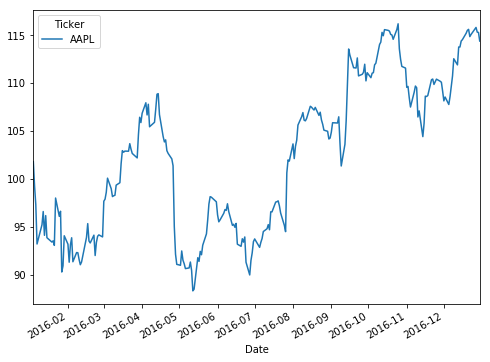

In [3]:
data=get_historical_closes(['AAPL'], '2016-01-01', '2016-12-31')
data.plot(figsize=(8,6));

In [35]:
aapl = web.Options('AAPL', 'yahoo')
appl_opt = aapl.get_all_data().reset_index()
appl_opt

,Strike,Expiry,Type,...,Quote_Time,Last_Trade_Date,JSON
0,2.5,2017-09-15,call,...,2017-09-07 18:17:47,2017-09-02 03:47:35,"{'currency': 'USD', 'expiration': 1505433600, ..."
1,2.5,2017-11-17,call,...,2017-09-07 18:17:47,2017-08-09 18:58:30,"{'currency': 'USD', 'expiration': 1510876800, ..."
2,2.5,2018-01-19,call,...,2017-09-07 18:17:47,2017-08-09 19:07:11,"{'currency': 'USD', 'expiration': 1516320000, ..."
3,2.5,2018-01-19,put,...,2017-09-07 18:17:47,2017-08-11 21:11:33,"{'currency': 'USD', 'expiration': 1516320000, ..."
4,5.0,2017-09-15,call,...,2017-09-07 18:17:47,2017-08-30 19:58:16,"{'currency': 'USD', 'expiration': 1505433600, ..."
...,...,...,...,...,...,...,...
1091,305.0,2017-09-15,put,...,2017-09-07 18:17:47,2017-08-30 19:51:13,"{'currency': 'USD', 'expiration': 1505433600, ..."
1092,305.0,2018-01-19,call,...,2017-09-07 18:17:47,2017-08-29 19:56:55,"{'currency': 'USD', 'expiration': 1516320000, ..."
1093,305.0,2018-01-19,put,...,2017-09-07 18:17:47,2017-07-24 18:37:53,"{'currency': 'USD', 'expiration': 1516320000, ..."
1094,305.0,2018-04-20,call,...,2017-09-07 18:17:47,2017-08-26 03:51:17,"{'currency': 'USD', 'expiration': 1524182400, ..."


In [47]:
appl_opt.JSON[0]

{'ask': 161.85,
 'bid': 161.2,
 'change': 0.0,
 'contractSize': 'REGULAR',
 'contractSymbol': 'AAPL170915C00002500',
 'currency': 'USD',
 'expiration': 1505433600,
 'impliedVolatility': 0.0,
 'inTheMoney': True,
 'lastPrice': 161.55,
 'lastTradeDate': 1504324055,
 'openInterest': 20,
 'percentChange': 0.0,
 'strike': 2.5,
 'volume': 20}

In [5]:
def calc_daily_returns(closes):
    return np.log(closes/closes.shift(1))[1:]

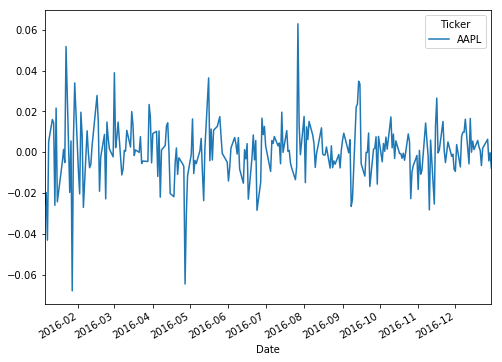

In [6]:
daily_returns=calc_daily_returns(data)
daily_returns.plot(figsize=(8,6));

# 2. Valución usando simulación: modelo normal para los rendimientos

In [7]:
mu=daily_returns.mean().AAPL
sigma=daily_returns.std().AAPL
ndays = 360
ntraj=10
dates=pd.date_range('20170101',periods=ndays)
simret = pd.DataFrame(sigma*np.random.randn(ndays,ntraj)+mu,index=dates)
simret

,0,1,2,...,7,8,9
2017-01-01,0.017,-0.005,0.011,...,0.006,3.009e-03,0.020
2017-01-02,0.016,-0.001,0.008,...,0.002,-5.797e-03,0.008
2017-01-03,-0.003,0.005,-0.012,...,-0.026,-2.103e-02,-0.018
2017-01-04,-0.016,-0.004,-0.040,...,-0.010,1.228e-02,0.023
2017-01-05,0.013,0.027,0.029,...,0.002,-8.048e-03,-0.030
...,...,...,...,...,...,...,...
2017-12-22,0.014,-0.027,-0.003,...,-0.012,2.917e-02,0.003
2017-12-23,-0.012,0.016,0.020,...,0.011,5.313e-02,0.002
2017-12-24,-0.023,0.012,-0.004,...,0.004,-7.888e-03,-0.009
2017-12-25,0.029,0.005,0.007,...,0.008,1.190e-02,-0.030


In [8]:
simdata=(data.loc['2016-12-30',:].AAPL)*np.exp(simret.cumsum())
simdata

,0,1,2,...,7,8,9
2017-01-01,116.414,113.875,115.689,...,115.099,114.741,116.728
2017-01-02,118.272,113.726,116.651,...,115.310,114.078,117.656
2017-01-03,117.907,114.285,115.220,...,112.325,111.704,115.550
2017-01-04,115.999,113.871,110.675,...,111.223,113.084,118.291
2017-01-05,117.550,116.966,113.918,...,111.499,112.177,114.748
...,...,...,...,...,...,...,...
2017-12-22,185.819,122.473,147.333,...,101.641,182.857,136.872
2017-12-23,183.555,124.419,150.344,...,102.717,192.835,137.081
2017-12-24,179.400,125.872,149.703,...,103.143,191.320,135.859
2017-12-25,184.596,126.547,150.789,...,103.937,193.610,131.866


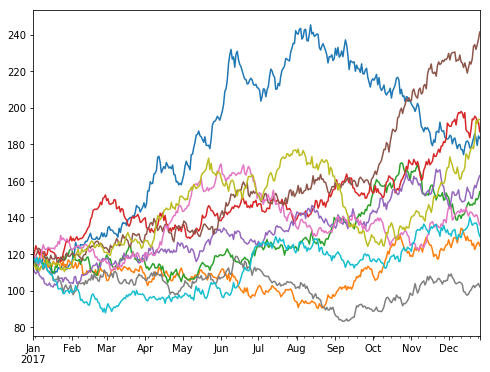

In [9]:
simdata.plot(figsize=(8,6),legend=False);

In [10]:
K=160
mu=daily_returns.mean().AAPL
sigma=daily_returns.std().AAPL
ndays = 360
ntraj=100
dates=pd.date_range('20170101',periods=ndays)
simret = pd.DataFrame(sigma*np.random.randn(ndays,ntraj)+mu,index=dates)
simdata=(data.loc['2016-12-30',:].AAPL)*np.exp(simret.cumsum())
strike = pd.DataFrame({'Strike':K*np.ones(ndays)},index=dates)
simul=pd.concat([data.T,strike.T,simdata.T]).T

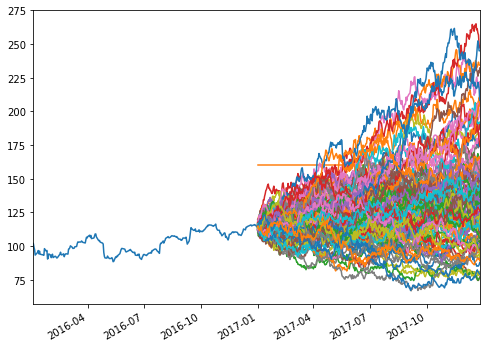

In [11]:
simul.plot(figsize=(8,6),legend=False);

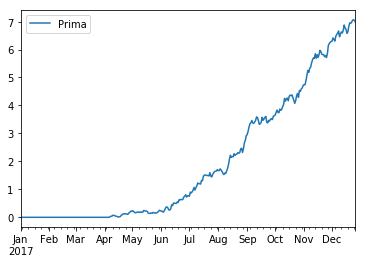

In [12]:
strike = pd.DataFrame(K*np.ones(ndays*ntraj).reshape((ndays,ntraj)),index=dates)
call=pd.DataFrame({'Prima':np.exp(-mu*ndays)*np.fmax(simdata-strike,np.zeros(ndays*ntraj).reshape((ndays,ntraj))).T.mean()},index=dates)
call.plot();

In [13]:
call.loc['2017-06-10']

Prima    0.26
Name: 2017-06-10 00:00:00, dtype: float64

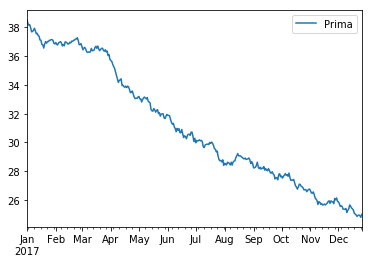

In [14]:
put=pd.DataFrame({'Prima':np.exp(-mu*ndays)*np.fmax(strike-simdata,np.zeros(ndays*ntraj).reshape((ndays,ntraj))).T.mean()},index=dates)
put.plot();

In [15]:
put.loc['2017-06-10']

Prima    30.747
Name: 2017-06-10 00:00:00, dtype: float64

# 3. Valución usando simulación: uso del histograma de los rendimientos

In [16]:
ndays = 360
ntraj=10
#
values,indices=np.histogram(daily_returns,bins=250)
values=values.astype(np.float32)
weights=values/np.sum(values)
ret=np.random.choice(indices[1:],ndays*ntraj,p=weights)
#
dates=pd.date_range('20170101',periods=ndays)
simret = pd.DataFrame(ret.reshape((ndays,ntraj)),index=dates)
simret

,0,1,2,...,7,8,9
2017-01-01,5.866e-03,4.819e-03,-0.031,...,1.060e-04,1.739e-02,0.010
2017-01-02,-1.508e-02,1.060e-04,0.009,...,-9.413e-04,1.529e-02,-0.011
2017-01-03,-5.654e-03,-8.272e-03,0.034,...,-4.607e-03,1.686e-02,-0.020
2017-01-04,-5.130e-03,1.153e-03,-0.005,...,4.819e-03,1.686e-02,-0.010
2017-01-05,-1.141e-02,-9.413e-04,0.028,...,-3.559e-03,1.060e-04,0.034
...,...,...,...,...,...,...,...
2017-12-22,7.960e-03,1.267e-02,-0.003,...,-2.660e-02,-1.465e-03,0.002
2017-12-23,1.060e-04,1.060e-04,0.006,...,1.215e-02,1.677e-03,0.013
2017-12-24,4.295e-03,1.529e-02,0.006,...,-2.241e-02,1.477e-02,0.009
2017-12-25,8.484e-03,1.058e-02,0.006,...,-3.036e-03,-2.512e-03,0.013


In [17]:
simdata=(data.loc['2016-12-30',:].AAPL)*np.exp(simret.cumsum())
simdata

,0,1,2,...,7,8,9
2017-01-01,115.070,114.949,110.928,...,114.409,116.403,115.492
2017-01-02,113.348,114.961,111.932,...,114.301,118.197,114.182
2017-01-03,112.709,114.014,115.759,...,113.776,120.206,111.944
2017-01-04,112.132,114.146,115.227,...,114.325,122.251,110.790
2017-01-05,110.859,114.039,118.482,...,113.919,122.263,114.637
...,...,...,...,...,...,...,...
2017-12-22,92.104,173.373,241.886,...,157.861,144.492,195.460
2017-12-23,92.113,173.391,243.309,...,159.791,144.735,197.953
2017-12-24,92.510,176.063,244.869,...,156.250,146.888,199.744
2017-12-25,93.298,177.935,246.439,...,155.776,146.519,202.291


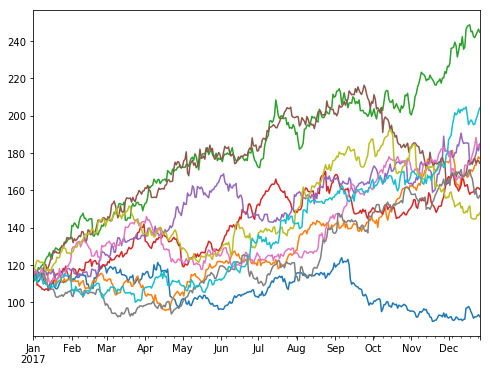

In [18]:
simdata.plot(figsize=(8,6),legend=False);

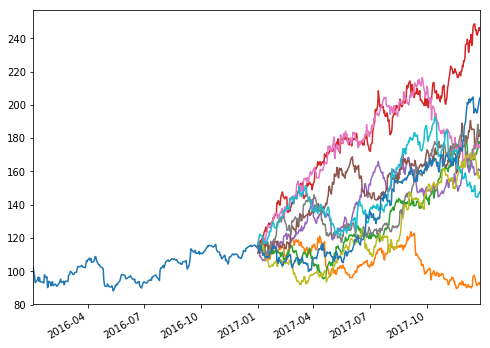

In [19]:
pd.concat([data,simdata]).plot(figsize=(8,6),legend=False);

In [20]:
K=160
ndays = 360
ntraj=1000
#
values,indices=np.histogram(daily_returns,bins=250)
values=values.astype(np.float32)
weights=values/np.sum(values)
ret=np.random.choice(indices[1:],ndays*ntraj,p=weights)
#
dates=pd.date_range('20170101',periods=ndays)
simret = pd.DataFrame(ret.reshape((ndays,ntraj)),index=dates)
simdata=(data.loc['2016-12-30',:].AAPL)*np.exp(simret.cumsum())
strike = pd.DataFrame({'Strike':K*np.ones(ndays)},index=dates)
simul=pd.concat([data.T,strike.T,simdata.T]).T

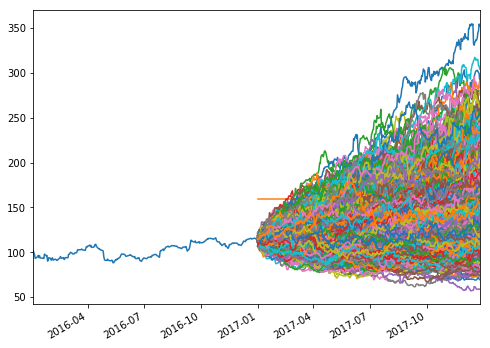

In [21]:
simul.plot(figsize=(8,6),legend=False);

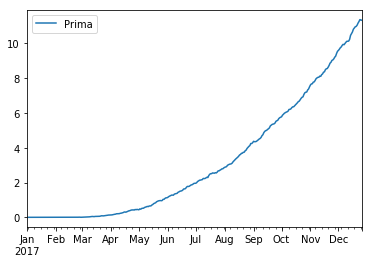

In [22]:
strike = pd.DataFrame(K*np.ones(ndays*ntraj).reshape((ndays,ntraj)),index=dates)
call=pd.DataFrame({'Prima':np.exp(-mu*ndays)*np.fmax(simdata-strike,np.zeros(ndays*ntraj).reshape((ndays,ntraj))).T.mean()},index=dates)
call.plot();

In [23]:
call.loc['2017-06-10']

Prima    1.363
Name: 2017-06-10 00:00:00, dtype: float64

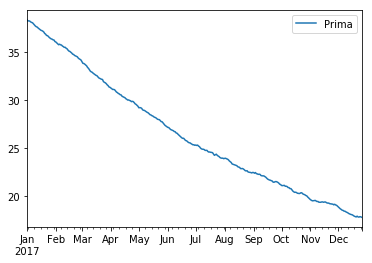

In [24]:
put=pd.DataFrame({'Prima':np.exp(-mu*ndays)*np.fmax(strike-simdata,np.zeros(ndays*ntraj).reshape((ndays,ntraj))).T.mean()},index=dates)
put.plot();

In [25]:
put.loc['2017-06-10']

Prima    26.591
Name: 2017-06-10 00:00:00, dtype: float64

# 4. Valución usando simulación: uso de la distrubición empírica aproximada con un método de kernel

In [26]:
kde = KernelDensity(kernel='gaussian', bandwidth=0.001).fit(daily_returns)
ndays = 360
ntraj=100
#
ret=kde.sample(n_samples=ndays*ntraj, random_state=None)
#
dates=pd.date_range('20170101',periods=ndays)
simret = pd.DataFrame(ret.reshape((ndays,ntraj)),index=dates)
simret

,0,1,2,...,97,98,99
2017-01-01,8.010e-03,-1.821e-02,-9.287e-04,...,-1.382e-02,-0.022,-3.415e-03
2017-01-02,-1.149e-02,-2.570e-02,9.385e-03,...,-2.562e-03,0.014,7.547e-03
2017-01-03,7.428e-03,-9.442e-03,-1.142e-02,...,-2.196e-02,-0.011,4.261e-04
2017-01-04,-1.124e-03,-5.516e-03,1.508e-02,...,4.950e-03,-0.004,-2.533e-02
2017-01-05,1.580e-02,-7.823e-03,1.735e-02,...,-5.763e-03,-0.019,9.511e-03
...,...,...,...,...,...,...,...
2017-12-22,-7.960e-03,-2.578e-02,-1.640e-02,...,8.881e-04,0.018,9.259e-03
2017-12-23,6.953e-04,7.045e-03,9.952e-03,...,-7.728e-03,0.008,-2.409e-02
2017-12-24,7.498e-03,3.234e-04,1.681e-02,...,3.623e-03,0.017,1.585e-02
2017-12-25,5.917e-03,-1.029e-02,4.374e-05,...,1.760e-02,0.004,-1.972e-02


In [27]:
simdata=(data.loc['2016-12-30',:].AAPL)*np.exp(simret.cumsum())
simdata

,0,1,2,...,97,98,99
2017-01-01,115.317,112.332,114.291,...,112.827,111.922,114.007
2017-01-02,114.000,109.482,115.368,...,112.538,113.495,114.870
2017-01-03,114.850,108.453,114.058,...,110.094,112.237,114.919
2017-01-04,114.720,107.857,115.791,...,110.640,111.749,112.045
2017-01-05,116.547,107.016,117.818,...,110.004,109.640,113.115
...,...,...,...,...,...,...,...
2017-12-22,210.934,101.254,139.282,...,140.320,138.753,109.741
2017-12-23,211.081,101.970,140.675,...,139.240,139.870,107.129
2017-12-24,212.669,102.003,143.059,...,139.745,142.331,108.841
2017-12-25,213.931,100.958,143.065,...,142.226,142.942,106.715


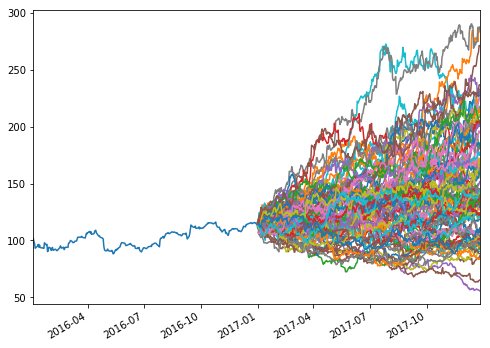

In [28]:
pd.concat([data,simdata]).plot(figsize=(8,6),legend=False);

In [29]:
K=160
ndays = 360
ntraj=1000
#
ret=kde.sample(n_samples=ndays*ntraj, random_state=None)
#
dates=pd.date_range('20170101',periods=ndays)
simret = pd.DataFrame(ret.reshape((ndays,ntraj)),index=dates)
simdata=(data.loc['2016-12-30',:].AAPL)*np.exp(simret.cumsum())
strike = pd.DataFrame({'Strike':K*np.ones(ndays)},index=dates)
simul=pd.concat([data.T,strike.T,simdata.T]).T

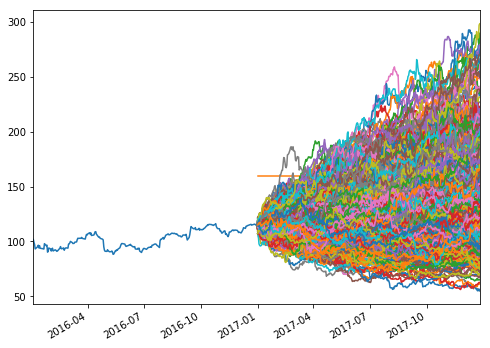

In [30]:
simul.plot(figsize=(8,6),legend=False);

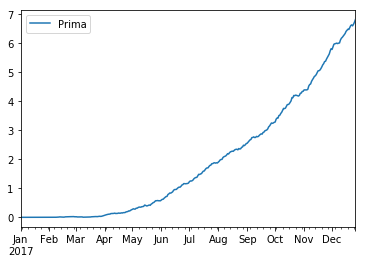

In [31]:
strike = pd.DataFrame(K*np.ones(ndays*ntraj).reshape((ndays,ntraj)),index=dates)
call=pd.DataFrame({'Prima':np.exp(-mu*ndays)*np.fmax(simdata-strike,np.zeros(ndays*ntraj).reshape((ndays,ntraj))).T.mean()},index=dates)
call.plot();

In [32]:
call.loc['2017-06-10']

Prima    0.837
Name: 2017-06-10 00:00:00, dtype: float64

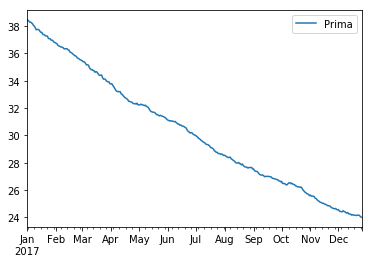

In [33]:
put=pd.DataFrame({'Prima':np.exp(-mu*ndays)*np.fmax(strike-simdata,np.zeros(ndays*ntraj).reshape((ndays,ntraj))).T.mean()},index=dates)
put.plot();

In [34]:
put.loc['2017-06-10']

Prima    30.941
Name: 2017-06-10 00:00:00, dtype: float64